In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Unemployment in India.csv")

print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
print(df.describe())

Shape: (768, 7)

Columns:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Data Types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Statistics:
       Estimated Unempl

In [6]:
#cleaning the data
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [7]:
# removing duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (741, 7)


In [8]:
print(df["Date"].head())

0     31-05-2019
1     30-06-2019
2     31-07-2019
3     31-08-2019
4     30-09-2019
Name: Date, dtype: object


In [9]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [12]:
print(df["Date"].head())

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


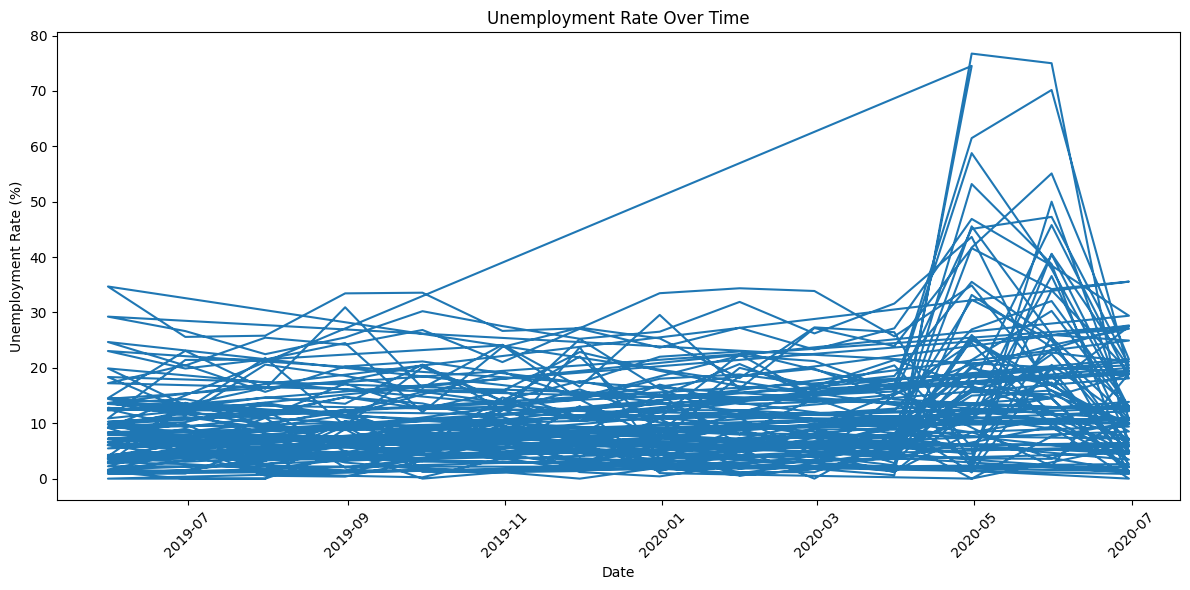

In [14]:
#unemployment trend
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Estimated Unemployment Rate (%)"])

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# COVID-19 impact
df["Period"] = np.where(
    df["Date"].dt.year < 2020,
    "Before COVID-19",
    "During/After COVID-19"
)

print(df.groupby("Period")["Estimated Unemployment Rate (%)"].mean())          #Average


Period
Before COVID-19           9.399047
During/After COVID-19    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


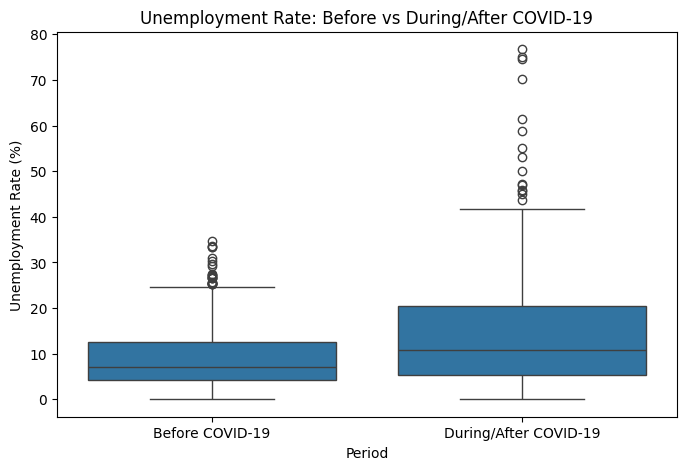

In [21]:
# Covid impact graph
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Period",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Unemployment Rate: Before vs During/After COVID-19")
plt.xlabel("Period")
plt.ylabel("Unemployment Rate (%)")

plt.show()

In [22]:
# Highest unemployment rate
highest = df.loc[
    df["Estimated Unemployment Rate (%)"].idxmax()
]

print("Highest Unemployment Rate:")
print(highest)

Highest Unemployment Rate:
Region                                                Puducherry
Date                                         2020-04-30 00:00:00
Frequency                                                Monthly
Estimated Unemployment Rate (%)                            76.74
Estimated Employed                                       68122.0
Estimated Labour Participation Rate (%)                    35.54
Area                                                       Urban
Period                                     During/After COVID-19
Name: 627, dtype: object


In [24]:
# Lowest unemployment rate
lowest = df.loc[
    df["Estimated Unemployment Rate (%)"].idxmin()
]

print("Lowest Unemployment Rate:")
print(lowest)

Lowest Unemployment Rate:
Region                                                     Assam
Date                                         2020-06-30 00:00:00
Frequency                                                Monthly
Estimated Unemployment Rate (%)                              0.0
Estimated Employed                                     7544937.0
Estimated Labour Participation Rate (%)                    34.38
Area                                                       Rural
Period                                     During/After COVID-19
Name: 25, dtype: object


In [26]:
  region_avg = df.groupby("Region")[
    "Estimated Unemployment Rate (%)"
].mean().sort_values(ascending=False)

print(region_avg)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


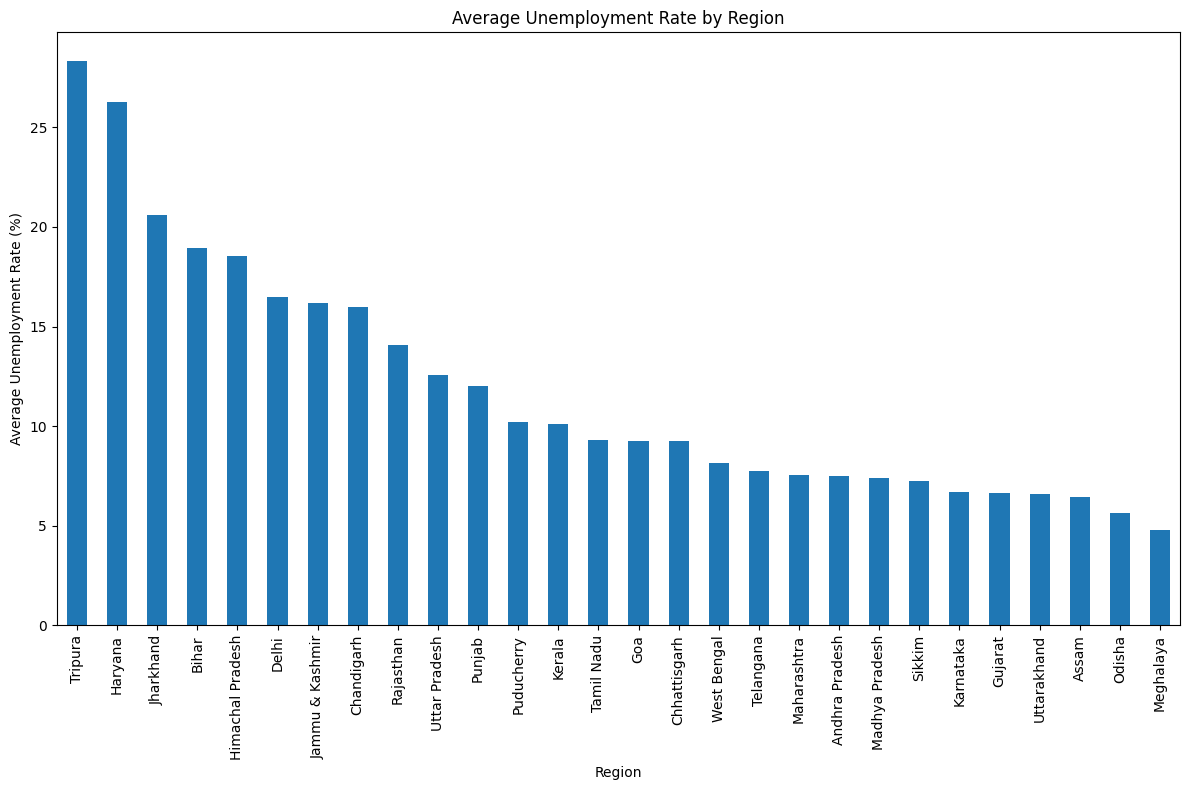

In [28]:
# regional unemployment graphs
plt.figure(figsize=(12, 8))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [35]:
# creating month column
df["Month"] = df["Date"].dt.month
print(df["Month"] )

0      5.0
1      6.0
2      7.0
3      8.0
4      9.0
      ... 
749    2.0
750    3.0
751    4.0
752    5.0
753    6.0
Name: Month, Length: 741, dtype: float64


In [37]:
# Average unemployment rate for each month
monthly_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

print(monthly_avg)

Month
1.0      9.950755
2.0      9.964717
3.0     10.700577
4.0     23.641569
5.0     16.646190
6.0     10.553462
7.0      9.033889
8.0      9.637925
9.0      9.051731
10.0     9.900909
11.0     9.868364
12.0     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


# **Insights**
Key Insights:

1. The unemployment rate changed significantly over time.
2. Unemployment increased during the COVID-19 period.
3. Unemployment rates varied across regions.
4. The monthly analysis shows variations in unemployment over the year.
5. These trends can help policymakers understand employment conditions and plan appropriate economic and social policies.

# **Conclusion**
The analysis revealed unemployment trends, regional differences, and the impact of COVID-19, providing useful insights into employment patterns.